<h3 style="background-color:#1E3A8A; color:white; padding:15px; border-radius:8px; font-family:Helvetica; text-align:center;">
    🚀 Data Preprocessing & Model building
</h3>


### Phase 6.1 : Final Dataset Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%store -r final_feature
%store -r consumer_feature

In [2]:
consumer_feature['PAR']=(
    consumer_feature['max_cons']/consumer_feature['mean_cons'].replace(0,np.nan)
)
consumer_feature['PAR'].fillna(0,inplace=True)

C:\Users\vinee\AppData\Local\Temp\ipykernel_18924\1555384415.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  consumer_feature['PAR'].fillna(0,inplace=True)


In [3]:
model_df = consumer_feature[
    final_feature + ['FLAG']
]
model_df=model_df.fillna(0)

In [4]:
model_df.shape
model_df.head()
model_df.info()
model_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42372 entries, 0 to 42371
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   std_cons                42372 non-null  float64
 1   zero_ratio              42372 non-null  float64
 2   high_cons_ratio         42372 non-null  float64
 3   PAR                     42372 non-null  float64
 4   cv                      42372 non-null  float64
 5   Stability               42372 non-null  float64
 6   longest_missing_streak  42372 non-null  int64  
 7   longest_zero_streak     42372 non-null  int64  
 8   FLAG                    42372 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 2.9 MB


,count,mean,std,min,25%,50%,75%,max
std_cons,42372.0,9.858840,254.292799,0.0,1.481244,3.279685,5.779500,27954.247106
zero_ratio,42372.0,0.179510,0.319867,0.0,0.000000,0.006944,0.168945,1.000000
high_cons_ratio,42372.0,0.356338,0.149869,0.0,0.306719,0.392912,0.450658,0.973913
PAR,42372.0,20.862290,88.457622,0.0,2.614051,3.650614,6.297518,1033.000000
cv,42372.0,0.621301,1.225096,0.0,0.298900,0.444721,0.672571,31.412916
Stability,42372.0,0.685358,0.156388,0.0,0.597845,0.692139,0.769782,1.000000
longest_missing_streak,42372.0,244.583003,296.187026,1.0,4.000000,84.000000,535.250000,1034.000000
longest_zero_streak,42372.0,56.385207,126.186124,0.0,0.000000,2.000000,40.000000,758.000000
FLAG,42372.0,0.085316,0.279354,0.0,0.000000,0.000000,0.000000,1.000000


In [5]:
print('duplicate rows',model_df.duplicated().sum())
model_df.drop_duplicates(inplace=True)

duplicate rows 1216


In [6]:
X = model_df.drop('FLAG',axis=1)
y = model_df['FLAG']

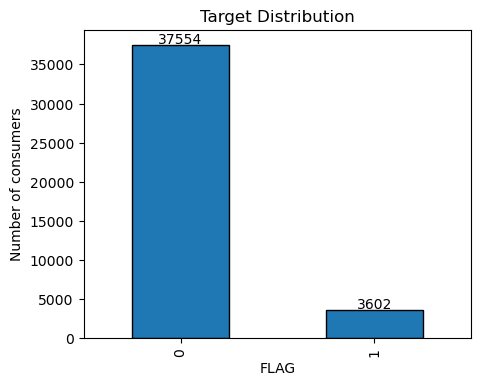

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
y.value_counts().plot(
    kind='bar',edgecolor='black'
)
plt.title("Target Distribution")
plt.xlabel("FLAG")
plt.ylabel("Number of consumers")
for i,v in enumerate(y.value_counts()):
    plt.text(i,v+100,str(v),ha='center',fontsize=10)
plt.show()

In [8]:
print(y.value_counts())
print(y.value_counts(normalize=True)*100)

FLAG
0    37554
1     3602
Name: count, dtype: int64
FLAG
0    91.247935
1     8.752065
Name: proportion, dtype: float64


#### Observation and work done 
- final dataset prepared 
- only selected features retained
- null values handled
- duplicate values removed 
- target variable seprated 
- dataset is imbalanced

### Phase 6.2 : Train-Test Split & Feature Scaling

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [10]:
# Check shape 
print('X_train',X_train.shape)
print('X_test',X_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (32924, 8)
X_test (8232, 8)
y_train (32924,)
y_test (8232,)


In [11]:
# verify class distribution 
print("Training test")
print(y_train.value_counts(normalize=True)*100)
print('Testing set')
print(y_test.value_counts(normalize=True)*100)

Training test
FLAG
0    91.246507
1     8.753493
Name: proportion, dtype: float64
Testing set
FLAG
0    91.253644
1     8.746356
Name: proportion, dtype: float64


### Phase 6.3 : Class Imbalance Handling

#### A model trained on imbalanced data may become biased so instead of direst appling oversampling, we will first esatablish a baseline model and then compare imbalanc handling techniques :
1. Original Dataset
2. Class Weight 
3. SMOTE Oversampling
#### best approach will be selected on Recall,F1 score, ROC-AUC and Precision.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import  Pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
baseline_lr = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(random_state=42,max_iter=1000))
])

In [14]:
baseline_lr.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [15]:
y_pred = baseline_lr.predict(X_test)
y_prob = baseline_lr.predict_proba(X_test)[:,1]

In [16]:
from sklearn.metrics import (
    classification_report,confusion_matrix,accuracy_score,roc_auc_score,ConfusionMatrixDisplay
)
print('Accuracy',accuracy_score(y_test,y_pred))
print('ROC AUC',roc_auc_score(y_test,y_pred))
print("Classification report")
print(classification_report(y_test,y_pred))

Accuracy 0.9125364431486881
ROC AUC 0.5
Classification report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      7512
           1       0.00      0.00      0.00       720

    accuracy                           0.91      8232
   macro avg       0.46      0.50      0.48      8232
weighted avg       0.83      0.91      0.87      8232



c:\Users\vinee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinee\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 600x600 with 0 Axes>

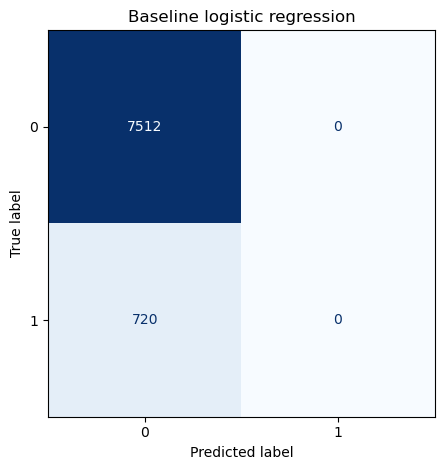

In [17]:
from sklearn.metrics import  ConfusionMatrixDisplay
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred,cmap='Blues',colorbar=False
)
plt.title("Baseline logistic regression")
plt.tight_layout()
plt.show()

#### Metrics Analysis
|metric|Value|interpretation|
|------|-----|--------------|
|Accurcy|91.25%|misleading|
|ROC-AUC|0.50|Random guessing|
|Fraud recall|0.00|all fraud missed|
|Fraud precision|0.00|fraud not predicted|
|fraud F1 score|0.00|model failed completely|

#### ***Business Interpretation*** 
although Logistic regression achieved an accuracy of **81.25%** but completely failed to indetify fraudulent consumers because of imbalanced dataset. 

### Phase 6.4 : Logistic Regression with class weight

In [18]:
lr_balanced = Pipeline([
    ('scaler',StandardScaler()),
    ('model',LogisticRegression(random_state=42,class_weight='balanced',max_iter=1000))
])

In [19]:
lr_balanced.fit(X_train,y_train)
y_pred_bal = lr_balanced.predict(X_test)
y_pron_bal = lr_balanced.predict_proba(X_test)[:,1]

In [20]:
print('accuracy :',accuracy_score(y_test,y_pred_bal))
print('ROC AUC :',roc_auc_score(y_test,y_pred_bal))
print('Classification report')
print(classification_report(y_test,y_pred_bal))

accuracy : 0.6118804664723032
ROC AUC : 0.6322528399006035
Classification report
              precision    recall  f1-score   support

           0       0.95      0.61      0.74      7512
           1       0.14      0.66      0.23       720

    accuracy                           0.61      8232
   macro avg       0.54      0.63      0.48      8232
weighted avg       0.88      0.61      0.70      8232



<Figure size 500x500 with 0 Axes>

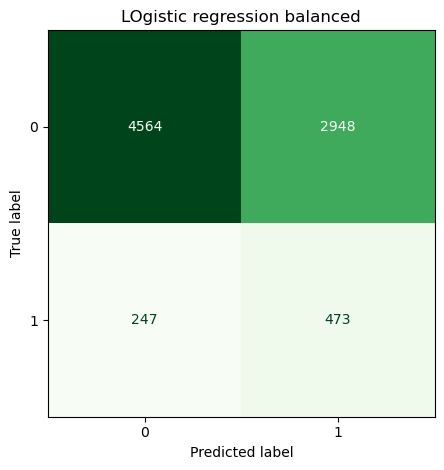

In [21]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_bal,cmap='Greens',colorbar=False
)
plt.title("LOgistic regression balanced")
plt.tight_layout()
plt.show()

#### Metrics Analysis
|metric|Baseline LR|Balanced LR|
|------|-----------|-----------|
|Accurcy|91.25%|61.19%|
|ROC-AUC|0.50|0.632|
|Fraud recall|0.00|0.66|
|Fraud precision|0.00|0.14|
|fraud F1 score|0.00|0.23|

#### Applying class weights significantly improved fraud detection capability. Fraud recall increased from 0% to approximately 66%, indicating that the model can now identify a majority of fraudulent consumers. However, this improvement comes at the cost of lower overall accuracy and a large number of false positives, resulting in low precision (14%). This highlights the trade-off between detecting more frauds and minimizing false alarms.

### Phase 6.5 – Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  (roc_auc_score,RocCurveDisplay,PrecisionRecallDisplay)

In [23]:
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs = -1
)
rf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [25]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nROC AUC :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9136297376093294

ROC AUC : 0.751751179594131

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.95      7512
           1       0.56      0.06      0.11       720

    accuracy                           0.91      8232
   macro avg       0.74      0.53      0.53      8232
weighted avg       0.89      0.91      0.88      8232



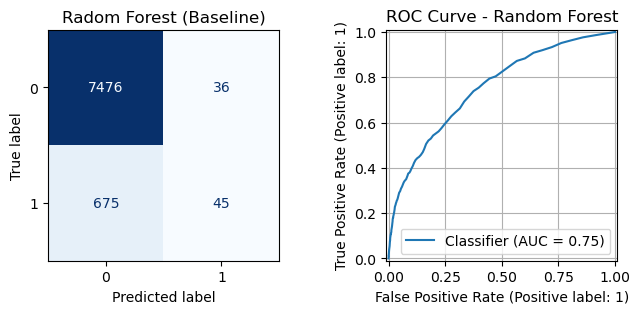

In [26]:
fig,ax=plt.subplots(1,2,figsize=(8,3))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_rf,cmap='Blues',colorbar=False,ax=ax[0]
)
ax[0].set_title("Radom Forest (Baseline)")
RocCurveDisplay.from_predictions(
    y_test,y_prob_rf,ax=ax[1]
)
ax[1].set_title("ROC Curve - Random Forest")
ax[1].grid()
plt.show()

In [27]:
fearture_imp = pd.DataFrame({
    'Feature' : X_train.columns,
    "Importance" : rf.feature_importances_
})
fearture_imp.sort_values(by='Importance',ascending=False)

,Feature,Importance
0,std_cons,0.187972
5,Stability,0.141713
3,PAR,0.138315
4,cv,0.138241
2,high_cons_ratio,0.135379
6,longest_missing_streak,0.110369
1,zero_ratio,0.082622
7,longest_zero_streak,0.065389


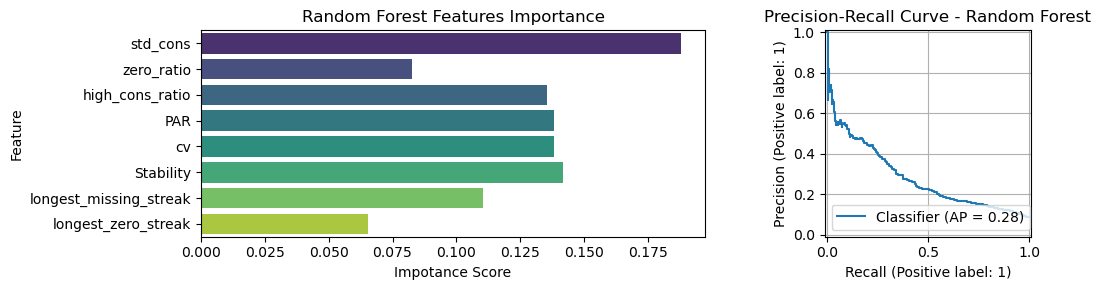

In [28]:

fig,ax=plt.subplots(1,2,figsize=(12,3))
sns.barplot(
    data=fearture_imp,x='Importance',y='Feature',
    palette='viridis',hue='Feature',legend=False,ax=ax[0]
)
ax[0].set_title("Random Forest Features Importance")
ax[0].set_xlabel("Impotance Score")
ax[0].set_ylabel("Feature")


PrecisionRecallDisplay.from_predictions(
    y_test,y_prob_rf,ax=ax[1]
)
ax[1].set_title("Precision-Recall Curve - Random Forest")
ax[1].grid()
plt.tight_layout()
plt.show()

#### Metrics Analysis
|metric|Baseline LR|Balanced LR|Random Forest(BL)|
|------|-----------|-----------|-----------------|
|Accurcy|91.25%|61.19%|91.36%|
|ROC-AUC|0.50|0.632|0.75|
|Fraud recall|0.00|0.66|0.06|
|Fraud precision|0.00|0.14|0.56|
|fraud F1 score|0.00|0.23|0.11|

### Phase 6.6 : Random Forest (Balanced)

In [29]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,random_state=42,class_weight='balanced',n_jobs=-1
)
rf_balanced.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf_balanced = rf_balanced.predict(X_test)
y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:,1]

In [31]:
print("Accuracy",accuracy_score(y_test,y_pred_rf_balanced))
print("ROC AUC", roc_auc_score(y_test,y_prob_rf_balanced))
print(classification_report(y_test,y_pred_rf_balanced))

Accuracy 0.9126579203109816
ROC AUC 0.7465885139332622
              precision    recall  f1-score   support

           0       0.92      1.00      0.95      7512
           1       0.51      0.04      0.07       720

    accuracy                           0.91      8232
   macro avg       0.71      0.52      0.51      8232
weighted avg       0.88      0.91      0.88      8232



In [32]:
fearture_imp = pd.DataFrame({
    'Feature' : X_train.columns,
    "Importance" : rf_balanced.feature_importances_
})
fearture_imp.sort_values(by='Importance',ascending=False)

,Feature,Importance
0,std_cons,0.202909
5,Stability,0.141754
4,cv,0.139614
3,PAR,0.131211
2,high_cons_ratio,0.128940
6,longest_missing_streak,0.116142
1,zero_ratio,0.076356
7,longest_zero_streak,0.063073


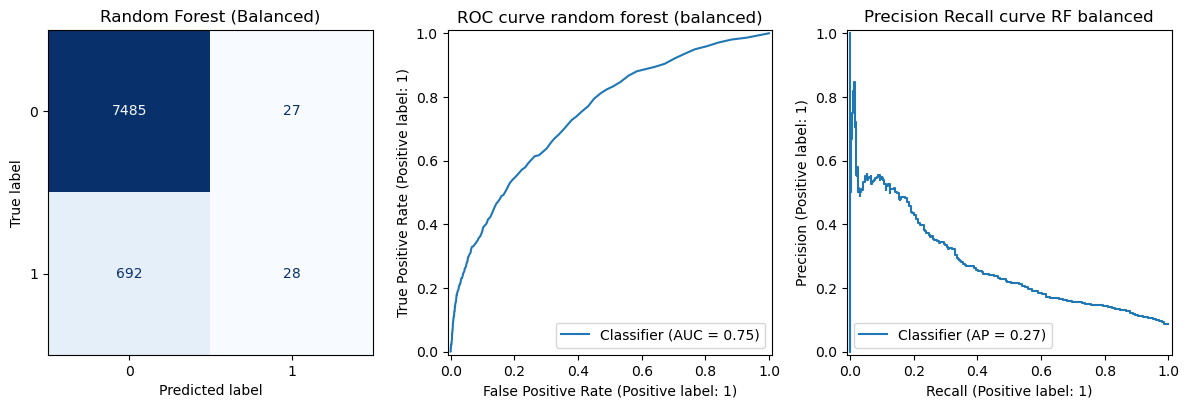

In [33]:
fig,ax=plt.subplots(1,3,figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred_rf_balanced,cmap='Blues',colorbar=False,ax=ax[0]
)
ax[0].set_title("Random Forest (Balanced)")

RocCurveDisplay.from_predictions(
    y_test,y_prob_rf_balanced,ax=ax[1]
)
ax[1].set_title('ROC curve random forest (balanced)')

PrecisionRecallDisplay.from_predictions(
    y_test,y_prob_rf_balanced,ax=ax[2]
)
ax[2].set_title('Precision Recall curve RF balanced')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Feature')

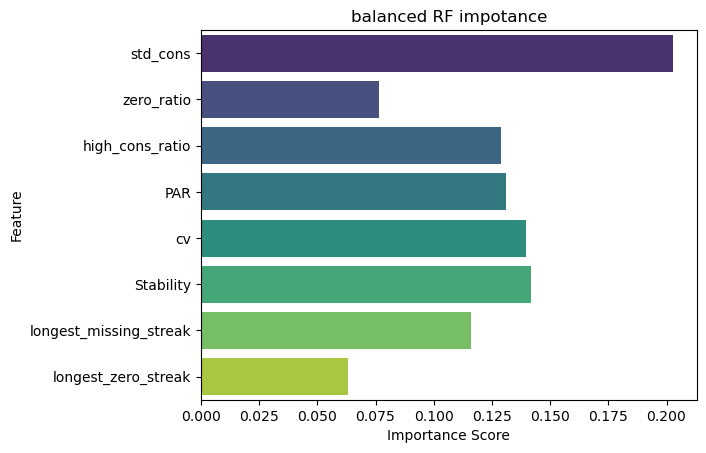

In [34]:
sns.barplot(
    data=fearture_imp,x='Importance',y='Feature',palette='viridis',
    hue='Feature'
)
plt.title("balanced RF impotance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")


#### Performance

| Metric | Value |
|---------|------:|
| Accuracy | 91.27% |
| ROC-AUC | 0.747 |
| Precision (Fraud) | 0.51 |
| Recall (Fraud) | 0.04 |
| F1-score | 0.07 |

- Overall accuracy remained approximately 91%.
- ROC-AUC remained close to the baseline Random Forest model.
- Precision remained acceptable at 51%.
- Recall decreased from 6% to 4%, indicating that the balanced class weights did not improve fraud detection.
- The model continued to classify the majority of fraud samples as normal consumers.


Applying `class_weight="balanced"` did not improve the performance of the Random Forest classifier. The model still produced very low recall for the minority class while maintaining high overall accuracy.

The ROC-AUC score (~0.75) indicates that the classifier has reasonable discriminative ability, suggesting that the poor recall is mainly due to the default classification threshold (0.5).

Therefore, the next step is to perform **Threshold Optimization**, where the probability cutoff will be adjusted to improve fraud detection while maintaining an acceptable precision-recall trade-off.

### Phase 6.7 – Threshold Tuning (Random Forest)

In [35]:
from sklearn.metrics import (precision_score,recall_score,f1_score)
thresholds=[
0.50,
0.45,
0.40,
0.35,
0.30,
0.25,
0.20,
0.15,
0.10
]

In [36]:
result=[]
for i in thresholds :
    y_pred= (y_prob_rf >= i).astype(int)
    results.append(
        {
            'Threshold':i,
            'Accuracy':accuracy_score(y_test,y_pred),
            'Precision':precision_score(y_test,y_pred,zero_division=0),
            'Recall':recall_score(y_test,y_pred),
            'F1':f1_score(y_test,y_pred)
        }
    )
threshold_df = pd.DataFrame(result)

NameError: name 'results' is not defined

In [ ]:
threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.913630,0.554217,0.063889,0.114570
1,0.45,0.913751,0.540323,0.093056,0.158768
2,0.40,0.912051,0.489362,0.127778,0.202643
3,0.35,0.909864,0.460714,0.179167,0.258000
4,0.30,0.904519,0.420673,0.243056,0.308099
5,0.25,0.889577,0.350238,0.306944,0.327165
6,0.20,0.858479,0.277722,0.386111,0.323068
7,0.15,0.805637,0.226368,0.505556,0.312715
8,0.10,0.700316,0.173458,0.644444,0.273343


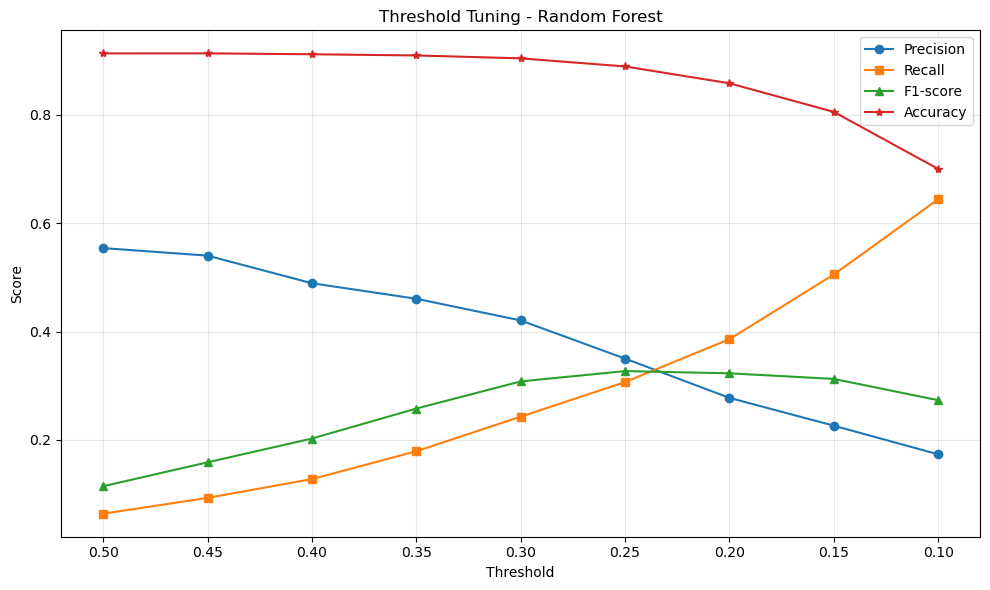

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="^",
    label="F1-score"
)
plt.plot(
    threshold_df['Threshold'],
    threshold_df['Accuracy'],
    marker="*",
    label='Accuracy'
)

plt.gca().invert_xaxis()

plt.grid(alpha=.3)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Tuning - Random Forest")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.250000
Accuracy     0.889577
Precision    0.350238
Recall       0.306944
F1           0.327165
Name: 5, dtype: float64


In [ ]:
best_threshold = best_row["Threshold"]

print("Best Threshold :", best_threshold)

y_pred_best = (
    y_prob_rf >= best_threshold
).astype(int)

Best Threshold : 0.25


              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7512
           1       0.35      0.31      0.33       720

    accuracy                           0.89      8232
   macro avg       0.64      0.63      0.63      8232
weighted avg       0.88      0.89      0.89      8232



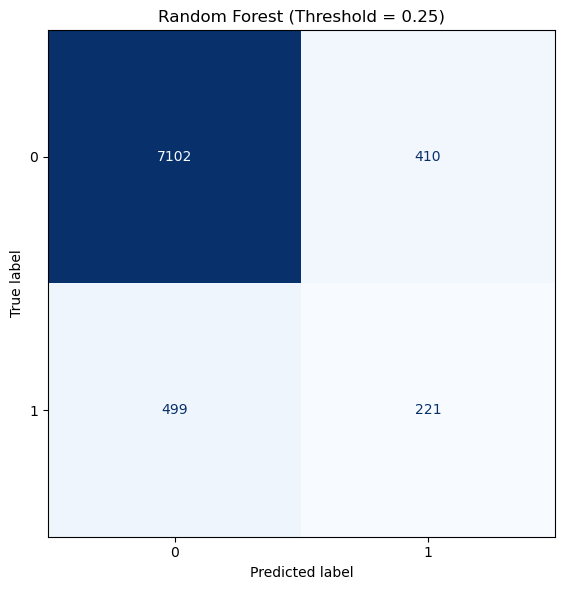

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print(classification_report(y_test,y_pred_best))

fig,ax=plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title(
    f"Random Forest (Threshold = {best_threshold:.2f})"
)

plt.tight_layout()

plt.show()

#### Threshold Tuning Summary 
##### Threshold tuning significantly improve the model's Recall along with maintaining acceptable precision. Since fraud detection prioritiezes minimizing False Negatives, the tuned threshold was selected deployment.

### Phase 6.8 : Random Forest Hyperparameter Tuning (GridSearchCV)

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt']
}

In [46]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

In [47]:
grid_rf.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [48]:
print('best parameter',grid_rf.best_params_)
print('bst CV recall',grid_rf.best_score_)

best parameter {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
bst CV recall 0.6773029799730407


In [49]:
best_rf=grid_rf.best_estimator_
y_pred=best_rf.predict(X_test)
y_prob=best_rf.predict_proba(X_test)[:,1]

In [ ]:
print("ACcruacy",accuracy_score(y_test,y_pred))
print("ROC AUC",roc_auc_score(y_test,y_prob))
print(classification_report(y_test,y_pred))


ACcruacy 0.6632653061224489
ROC AUC 0.7462938002899066
              precision    recall  f1-score   support

           0       0.96      0.66      0.78      7512
           1       0.17      0.70      0.27       720

    accuracy                           0.66      8232
   macro avg       0.56      0.68      0.52      8232
weighted avg       0.89      0.66      0.74      8232



In [51]:
important = pd.Series(
    best_rf.feature_importances_,index=X_train.columns
).sort_values()

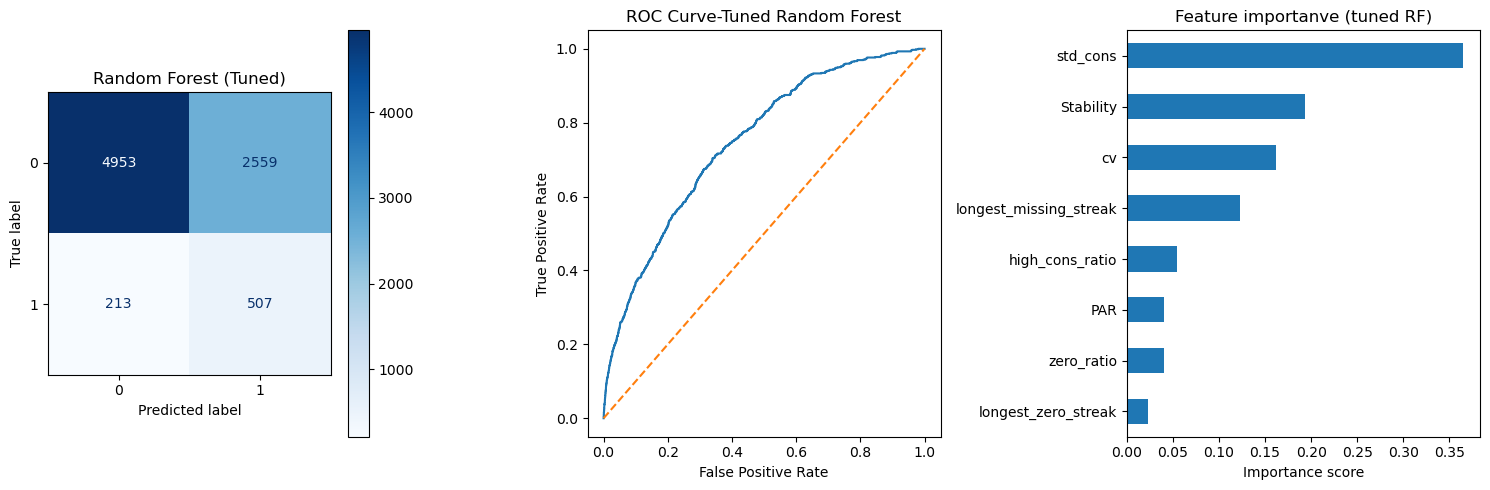

In [ ]:
from sklearn.metrics import roc_curve
fig,ax= plt.subplots(1,3,figsize=(15,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,y_pred,cmap='Blues',ax=ax[0])

fpr,tpr,_= roc_curve(y_test,y_prob)
ax[1].plot(
    fpr,tpr,
    label=f'AUC = {roc_auc_score(y_test,y_prob):.2f}')
ax[1].plot([0,1],[0,1],'--')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve-Tuned Random Forest")

important.plot(kind='barh',ax=ax[2])
ax[2].set_title("Feature importanve (tuned RF)")
ax[2].set_xlabel("Importance score")

plt.tight_layout()
ax[0].set_title("Random Forest (Tuned)")
plt.show()

#### Performance 
|Metric|score|
|------|-----|
|Accuracy|66.33%|
|ROC AUC|0.746|
|Fraud Recall|70%|
|Fraud Precision|17%|

#### Observations
- Hyperparameter tuning significantly improve fraud detection capabiliity
- The tuned model correctly identify 507 fraud consumer while missing 213 
- Accuracy decreased because the classifier bacame more sensitive toward minors
- ROC AUC remained strong shows good discrimination beteween fraud and normal cosumer
- consumption variability (std),stability and CV are the strongest predictors of fraud

### Phase 6.9 : Final Model Comparison 

In [52]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Logistic Regression (Balanced)','Random Forest',
    'Random Forest (Banalcefd)','Random Forest (Threshold=0.25)','Random Forest (Tuned)'],
    'Accuracy':[0.913,0.612,0.914,0.913,0.890,0.663],
    "Recall":[0.00,0.66,0.06,0.04,0.31,0.70],
    "F1 Score":[0.00,0.23,0.11,0.07,0.33,0.27],
    "ROC AUC":[0.50,0.632,0.752,0.747,0.752,0.746]
})        
comparison


,Model,Accuracy,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.913,0.00,0.00,0.500
1,Logistic Regression (Balanced),0.612,0.66,0.23,0.632
2,Random Forest,0.914,0.06,0.11,0.752
3,Random Forest (Banalcefd),0.913,0.04,0.07,0.747
4,Random Forest (Threshold=0.25),0.890,0.31,0.33,0.752
5,Random Forest (Tuned),0.663,0.70,0.27,0.746


In [ ]:
comparison.style.highlight_max(
    subset=['Recall','ROC AUC','F1 Score'],color='blue'
)

,Model,Accuracy,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.913000,0.000000,0.000000,0.500000
1,Logistic Regression (Balanced),0.612000,0.660000,0.230000,0.632000
2,Random Forest,0.914000,0.060000,0.110000,0.752000
3,Random Forest (Banalcefd),0.913000,0.040000,0.070000,0.747000
4,Random Forest (Threshold=0.25),0.890000,0.310000,0.330000,0.752000
5,Random Forest (Tuned),0.663000,0.700000,0.270000,0.746000


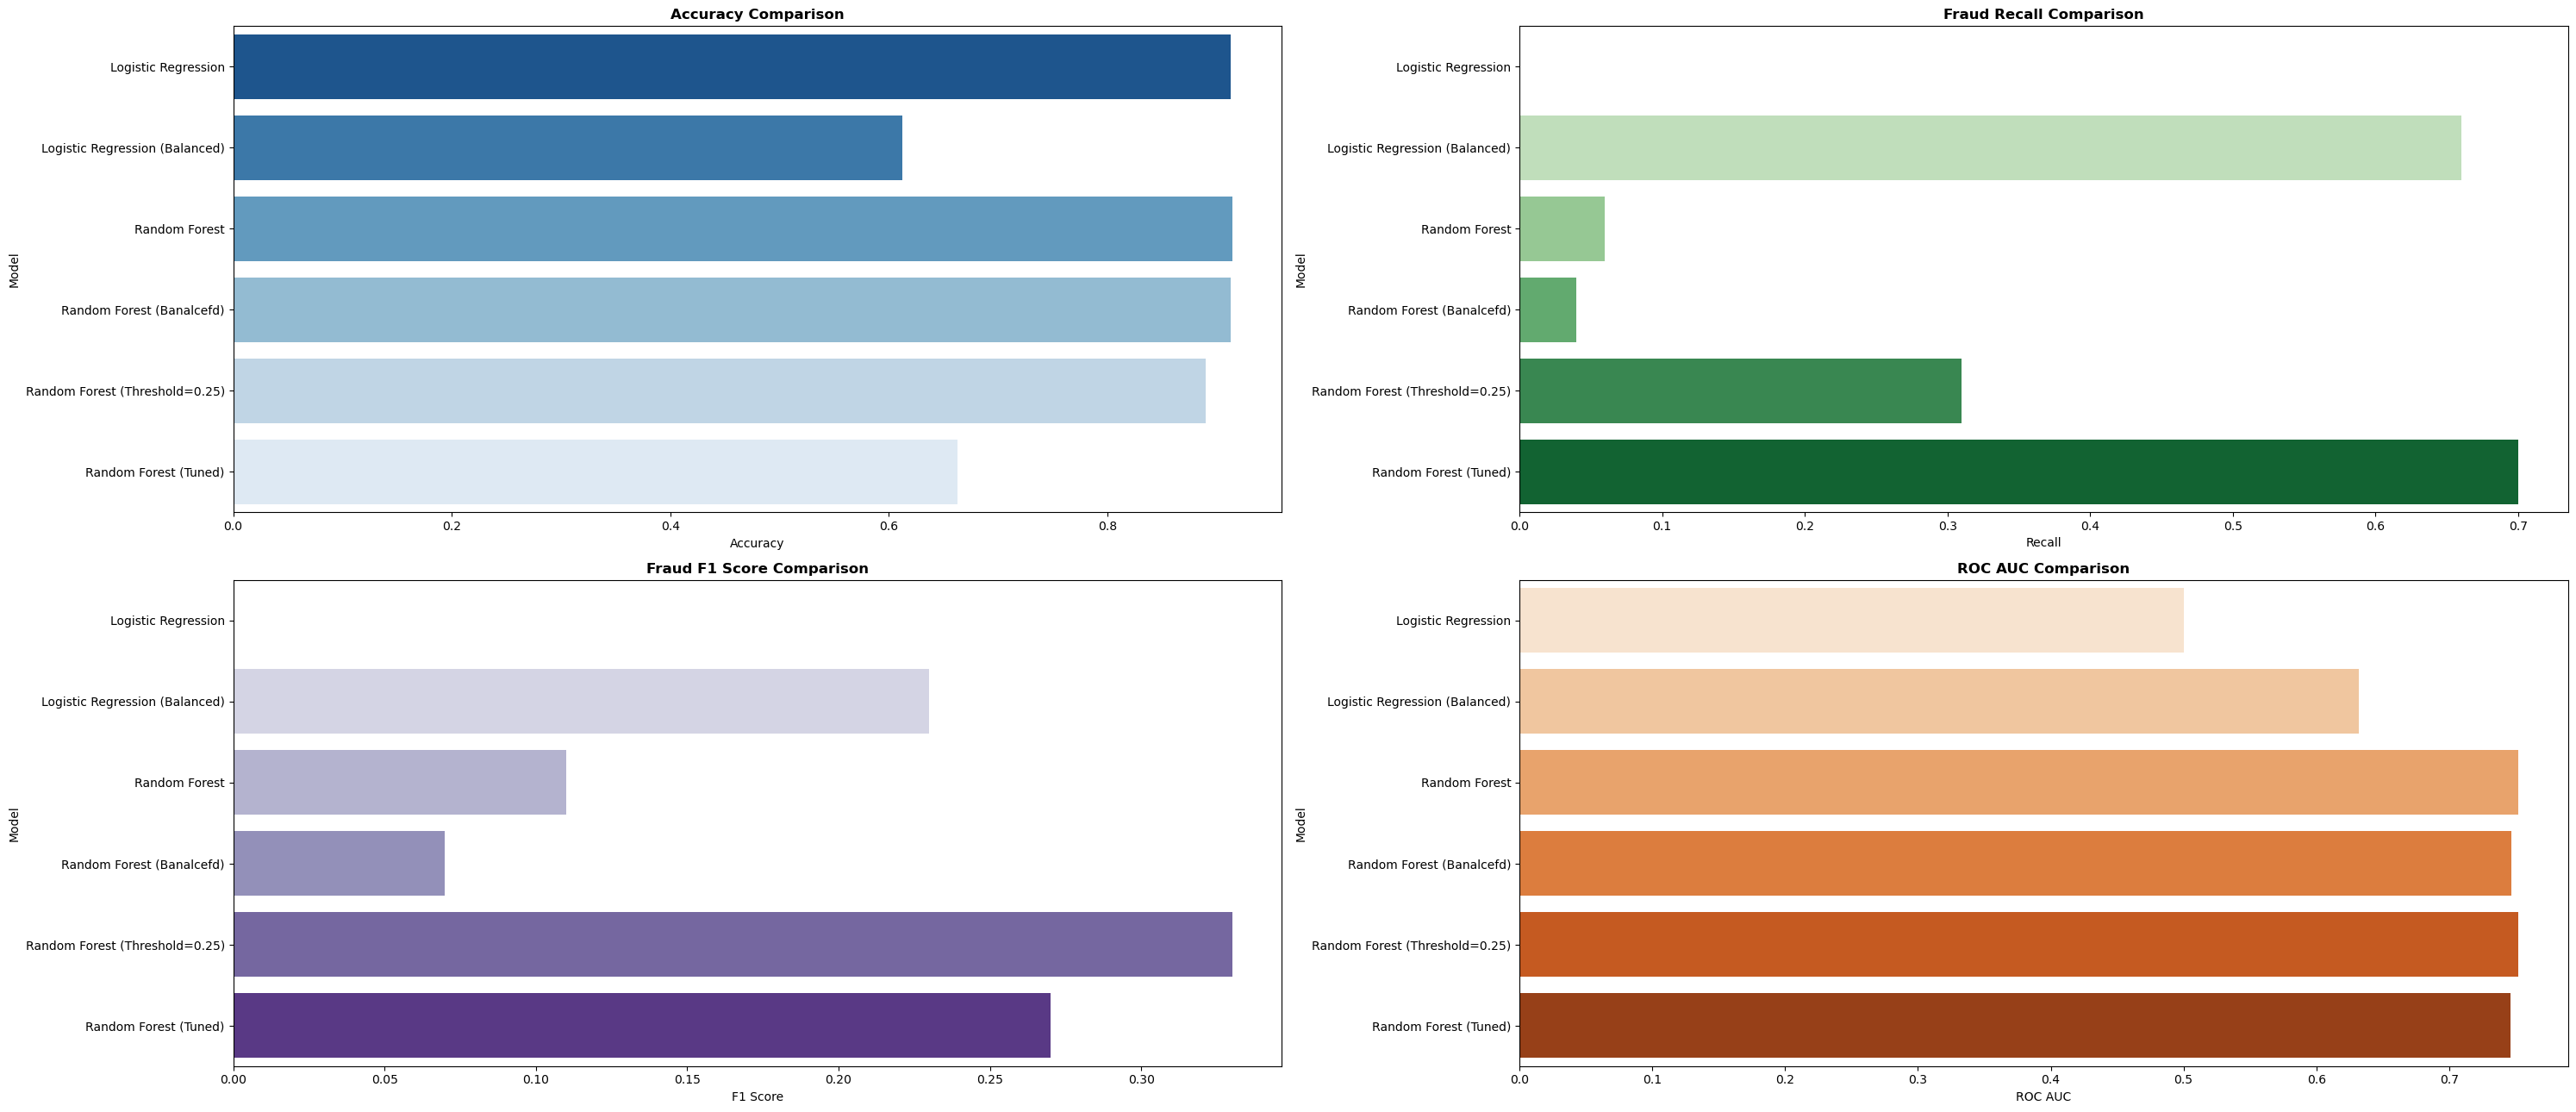

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(30,13))
sns.barplot(
    data=comparison,x='Accuracy',y='Model',palette='Blues_r',ax=ax[0,0],hue='Model'
)
sns.barplot(
    data=comparison,x='Recall',y='Model',palette='Greens',ax=ax[0,1],hue='Model'
)
sns.barplot(
    data=comparison,x='F1 Score',y='Model',palette='Purples',ax=ax[1,0],hue='Model'
)
sns.barplot(
    data=comparison,x='ROC AUC',y='Model',palette='Oranges',ax=ax[1,1],hue='Model'
)
ax[0,0].set_title('Accuracy Comparison',fontweight='bold')
ax[0,1].set_title('Fraud Recall Comparison',fontweight='bold')
ax[1,1].set_title('ROC AUC Comparison',fontweight='bold')
ax[1,0].set_title('Fraud F1 Score Comparison',fontweight='bold')

plt.tight_layout()

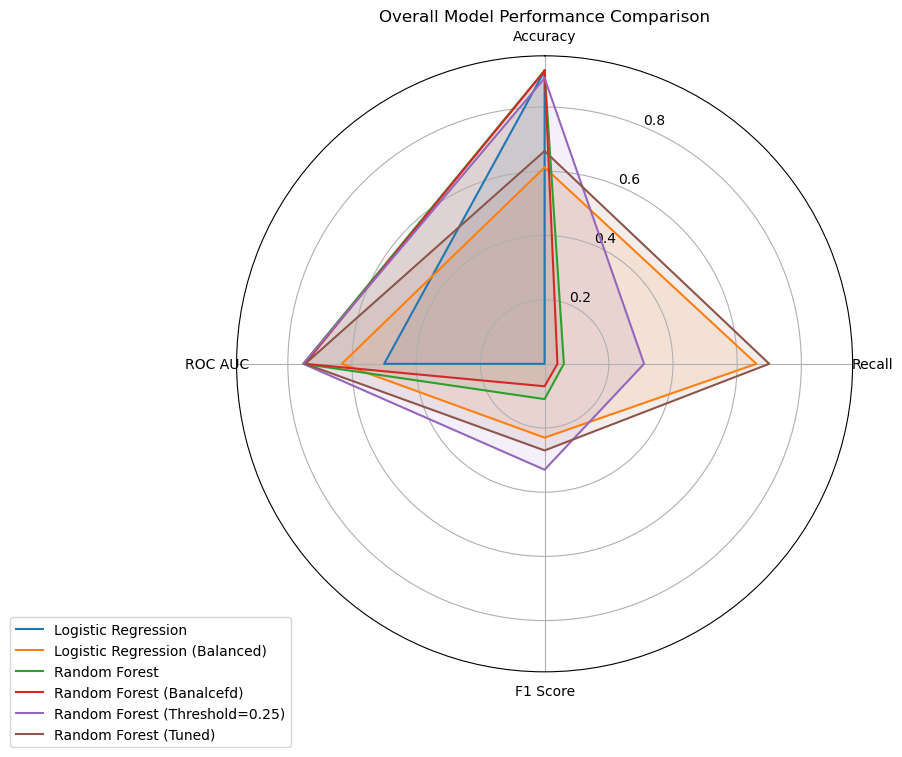

In [ ]:
metrics = ['Accuracy', 'Recall', 'F1 Score', 'ROC AUC']
num_vars = len(metrics)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Loop through each model in your dataframe
for model_name, row in comparison.set_index('Model')[metrics].iterrows():
  values = row.values.tolist()
  values += values[:1]  # Close the loop
  ax.plot(angles, values, label=model_name)
  ax.fill(angles, values, alpha=0.1)

# Fix axis labels and grid
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics)

plt.title('Overall Model Performance Comparison')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()


#### Final Model Comparison

Six classification models were evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

#### Key Findings

##### Logistic Regression
- Failed to detect fraud.
- High accuracy due to class imbalance.
- Not suitable for deployment.

##### Logistic Regression (Balanced)
- Significant improvement in recall.
- Accuracy decreased because more fraud cases were detected.
- Suitable as a baseline imbalance-aware model.

##### Random Forest
- Achieved excellent ROC-AUC.
- Very high accuracy.
- Poor recall for fraud detection.

##### Random Forest (Balanced)
- Class weighting alone did not significantly improve recall.
- Overall performance remained similar to the baseline Random Forest.

##### Random Forest (Threshold = 0.25)
- Improved recall compared with the default threshold.
- Demonstrated that threshold optimization can increase fraud detection without retraining the model.

##### Tuned Random Forest
- Achieved the highest fraud recall.
- ROC-AUC remained competitive.
- Accuracy decreased due to increased sensitivity toward fraudulent consumers.
- Best overall model for electricity fraud detection.

#### Final Selected Model

**Random Forest (Tuned)**

Reasons:
- Highest Recall
- Competitive ROC-AUC
- Better fraud detection capability
- Suitable for real-world electricity theft detection where minimizing missed fraud cases is more important than maximizing accuracy.

#### Final Model Comparison

Six classification models were evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

##### Key Findings

##### Logistic Regression
- Failed to detect fraud.
- High accuracy due to class imbalance.
- Not suitable for deployment.

##### Logistic Regression (Balanced)
- Significant improvement in recall.
- Accuracy decreased because more fraud cases were detected.
- Suitable as a baseline imbalance-aware model.

##### Random Forest
- Achieved excellent ROC-AUC.
- Very high accuracy.
- Poor recall for fraud detection.

##### Random Forest (Balanced)
- Class weighting alone did not significantly improve recall.
- Overall performance remained similar to the baseline Random Forest.

##### Random Forest (Threshold = 0.25)
- Improved recall compared with the default threshold.
- Demonstrated that threshold optimization can increase fraud detection without retraining the model.

##### Tuned Random Forest
- Achieved the highest fraud recall.
- ROC-AUC remained competitive.
- Accuracy decreased due to increased sensitivity toward fraudulent consumers.
- Best overall model for electricity fraud detection.

### Final Selected Model
**Random Forest (Tuned)**
Reasons:
- Highest Recall
- Competitive ROC-AUC
- Better fraud detection capability
- Suitable for real-world electricity theft detection where minimizing missed fraud cases is more important than maximizing accuracy.

### Phase 6.10 : Model Explainability (SHAP)

In [ ]:
import shap
from sklearn.inspection import permutation_importance

In [ ]:
explainer= shap.TreeExplainer(best_rf)

In [ ]:
shap_values = explainer(X_test)
shap_values_class1=shap_values[:,:,1]

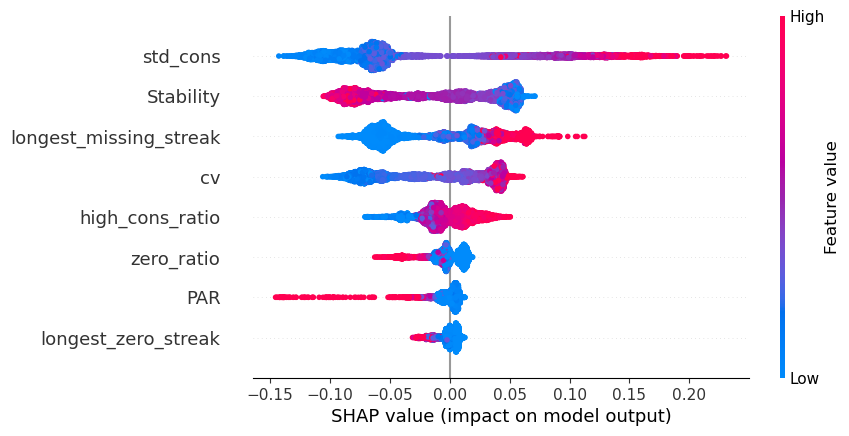

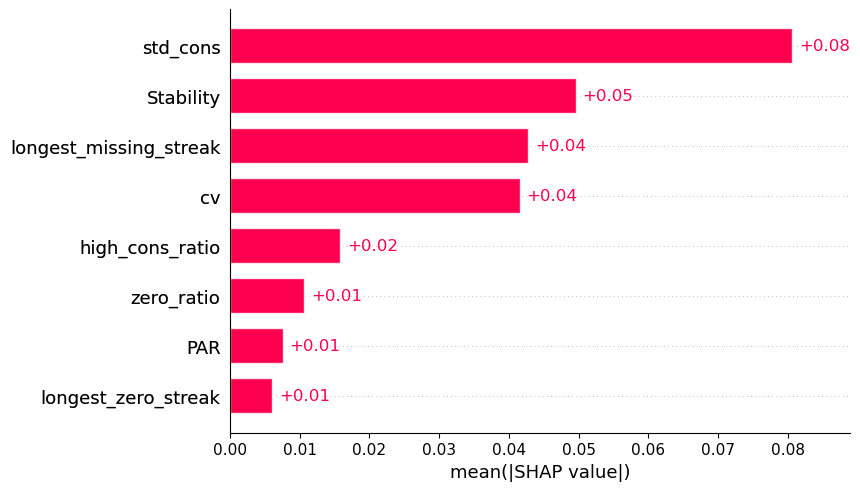

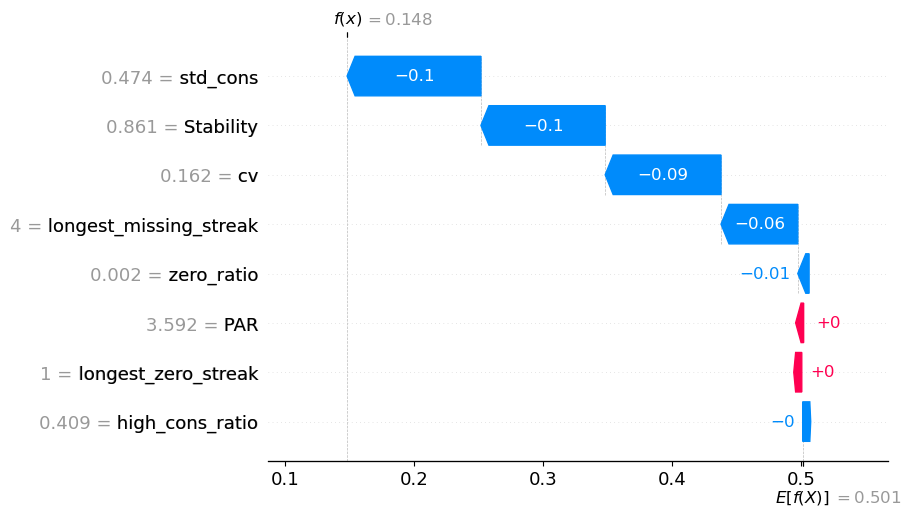

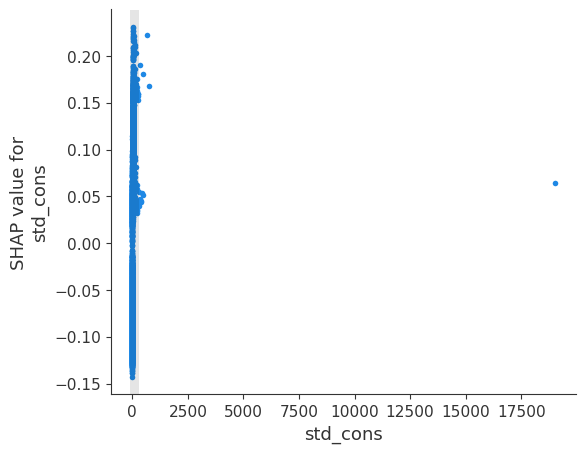

In [ ]:
shap.plots.beeswarm(shap_values[:,:,1],max_display=10)
shap.plots.bar(shap_values[:,:,1],max_display=10)
shap.plots.waterfall(shap_values_class1[10])
shap.plots.scatter(shap_values_class1[:,'std_cons'])

#### Key Findings

- `std_cons` is the most influential feature. Higher consumption variability strongly increases fraud probability.
- `Stability` is the second most important feature. Consumers with stable electricity usage are less likely to be classified as fraudulent.
- `longest_missing_streak` has a significant positive impact on fraud prediction, indicating that prolonged missing readings are suspicious.
- `cv` (Coefficient of Variation) also contributes positively, showing that irregular consumption patterns increase fraud risk.
- `high_cons_ratio` has moderate influence, whereas `zero_ratio`, `PAR`, and `longest_zero_streak` contribute comparatively less.

### Phase 6.11 : Export Productionn Artifacts

In [54]:
%store X_train
%store X_test
%store y_train
%store y_test
%store best_rf
%store comparison
%store important


Stored 'X_train' (DataFrame)
Stored 'X_test' (DataFrame)
Stored 'y_train' (Series)
Stored 'y_test' (Series)
Stored 'best_rf' (RandomForestClassifier)
Stored 'comparison' (DataFrame)
Stored 'important' (Series)
